# Project Python Foundations: FoodHub Data Analysis

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [3]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

In [ ]:
# to restrict the float value to 3 decimal places
pd.set_option('display.float_format', lambda x: '%.3f' % x)

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [5]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [6]:
# Write your code here to read the data
df=pd.read_csv('/content/drive/MyDrive/Python Course/Project 1-FoodHub/foodhub_order.csv')

In [7]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [8]:
# Write your code here
df.shape

(1898, 9)

#### Observations:There are 1898 Rows and 9 Columns

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [9]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:Rating should not be in 'string' data type.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [10]:
# Write your code here
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


In [11]:
df['rating'].dtype

dtype('O')

#### Observations:In 'rating' column 'string' need to replace with 'nan' value


In [12]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [13]:
print(df['rating'].dtype)

float64


In [14]:
df.duplicated().sum()

np.int64(0)

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [15]:
# Write your code here
df.describe()

,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1162.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,4.344234,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,0.741478,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,3.000000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,4.000000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,5.000000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,5.000000,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,5.000000,35.000000,33.000000


#### Observations:
Minimum Time:15mins

---


Average Time:24.16mins

---


Maximum Time:33mins

---










### **Question 5:** How many orders are not rated? [1 mark]

In [16]:
# Write the code here
df.rating.isnull().sum()

np.int64(736)

736 orders are not rated.

In [17]:
df['rating'] = df['rating'].fillna(df['rating'].mean())

In [18]:
df.rating.isnull().sum()

np.int64(0)

#### Observations: Missing values filled with mean.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

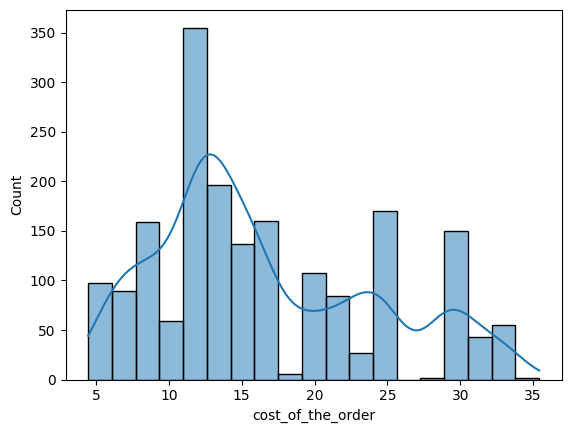

In [ ]:
# Write the code here
sns.histplot(data=df,x='cost_of_the_order',kde=True)
plt.savefig("output.jpg", bbox_inches='tight')

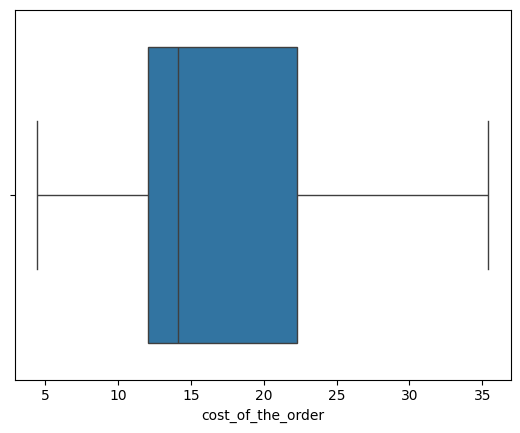

In [ ]:
sns.boxplot(data=df,x='cost_of_the_order')
plt.savefig("output.jpg", bbox_inches='tight')

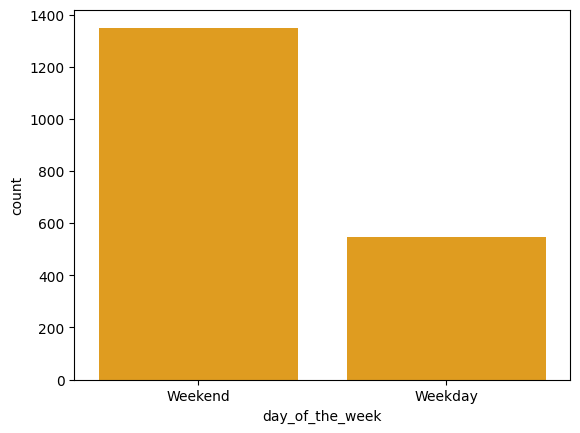

In [ ]:
sns.countplot(data=df, x='day_of_the_week',color='orange')
plt.savefig("output.jpg", bbox_inches='tight')

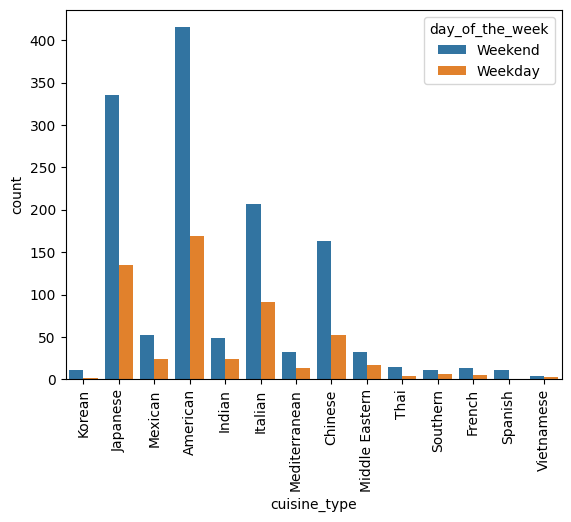

In [ ]:
sns.countplot(data=df,x='cuisine_type',hue='day_of_the_week')
plt.xticks(rotation=90)
plt.show()

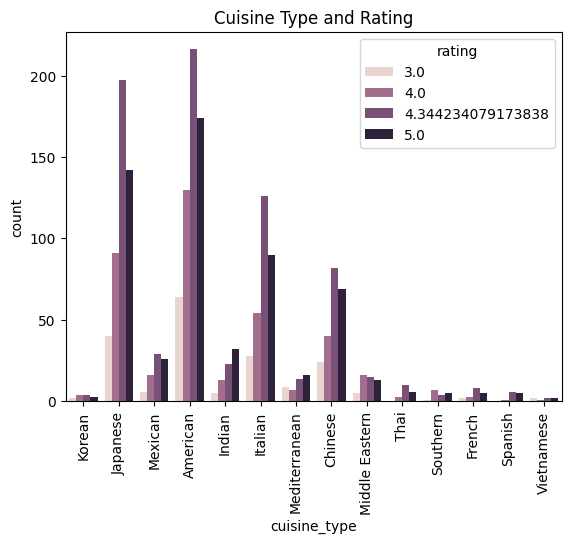

In [ ]:
sns.countplot(data=df,x='cuisine_type',hue='rating')
plt.xticks(rotation=90)
plt.title('Cuisine Type and Rating')
plt.savefig("output.jpg", bbox_inches='tight')
plt.show()


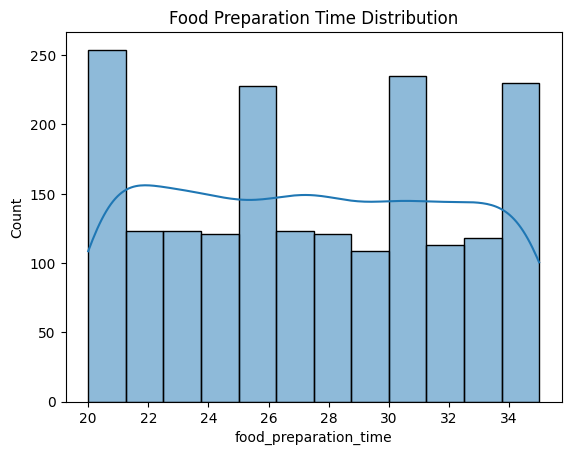

In [ ]:
sns.histplot(df['food_preparation_time'], kde=True)
plt.title('Food Preparation Time Distribution')
plt.savefig("output.jpg", bbox_inches='tight')

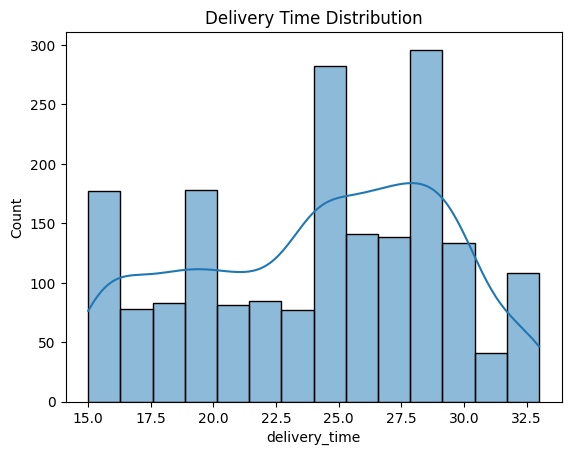

In [ ]:
sns.histplot(df['delivery_time'], kde=True)
plt.title('Delivery Time Distribution')
plt.savefig("output.jpg", bbox_inches='tight')

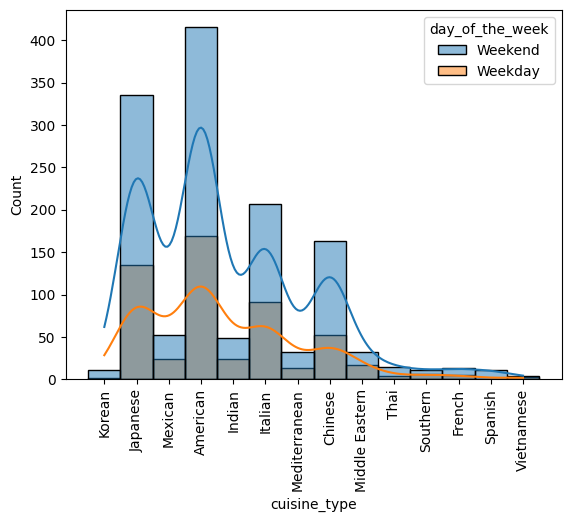

In [ ]:
sns.histplot(data=df,x='cuisine_type',hue='day_of_the_week',kde=True)
plt.xticks(rotation=90)
plt.savefig("output.jpg", bbox_inches='tight')

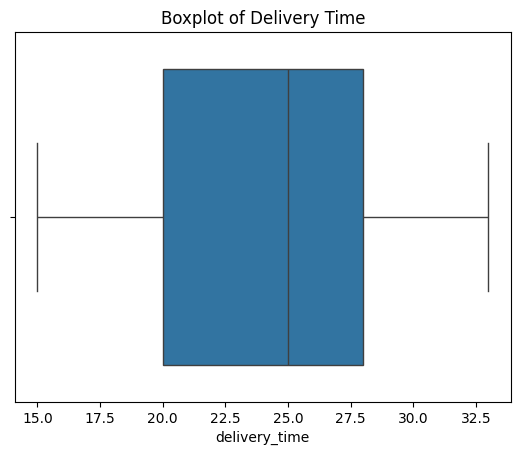

In [ ]:
sns.boxplot(x=df['delivery_time'])
plt.title('Boxplot of Delivery Time')
plt.savefig("output.jpg", bbox_inches='tight')

Median Delivery Time is around 25 minutes.
Most delivery times fall between 20 and 28 minutes.
There are no extreme outliers in delivery times.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

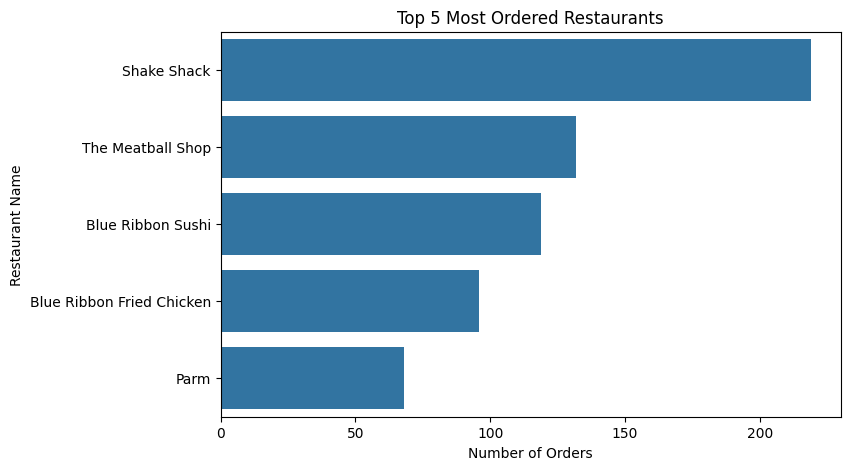

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(y='restaurant_name', data=df, order=df['restaurant_name'].value_counts().index[:5])
plt.savefig("output.jpg", bbox_inches='tight')
plt.title("Top 5 Most Ordered Restaurants")
plt.xlabel("Number of Orders")
plt.ylabel("Restaurant Name")
plt.show()

#### Observations:


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Write the code here
c_type=df.groupby('day_of_the_week')['cuisine_type'].value_counts()
print(c_type)

day_of_the_week  cuisine_type  
Weekday          American          169
                 Japanese          135
                 Italian            91
                 Chinese            52
                 Indian             24
                 Mexican            24
                 Middle Eastern     17
                 Mediterranean      14
                 Southern            6
                 French              5
                 Thai                4
                 Vietnamese          3
                 Korean              2
                 Spanish             1
Weekend          American          415
                 Japanese          335
                 Italian           207
                 Chinese           163
                 Mexican            53
                 Indian             49
                 Mediterranean      32
                 Middle Eastern     32
                 Thai               15
                 French             13
                 Korean         

#### Observations:
"American" Cuisine type is most popular on Weekends.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Write the code here
total_order_20=df[df['cost_of_the_order']>20].shape[0]
total_percentage=(total_order_20/df.shape[0])*100
print(total_percentage)

29.24130663856691


#### Observations: 29.24% of orders cost more than 20 dollars.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Write the code here
df['delivery_time'].mean()

np.float64(24.161749209694417)

#### Observations: Mean order delivery time is 24.16mins


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Write the code here
top_three=df['customer_id'].value_counts()[:3]
print(top_three)

customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64


#### Observations: Customer Ids- 52832,47440,83287 placed 13,10 and 9 orders respectively.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


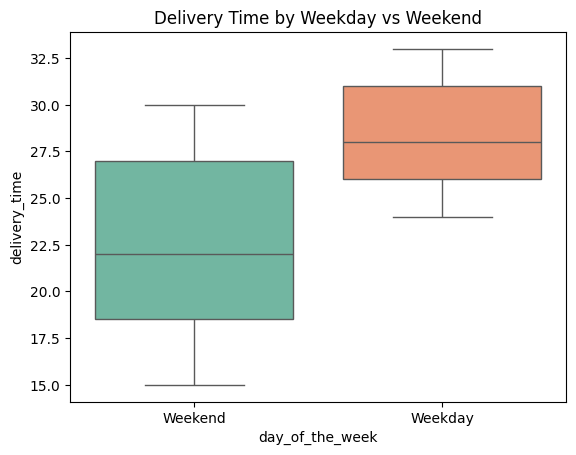

In [ ]:
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time',hue='day_of_the_week', palette='Set2',legend=False)
plt.title('Delivery Time by Weekday vs Weekend')
plt.savefig("output.jpg", bbox_inches='tight')
plt.show()

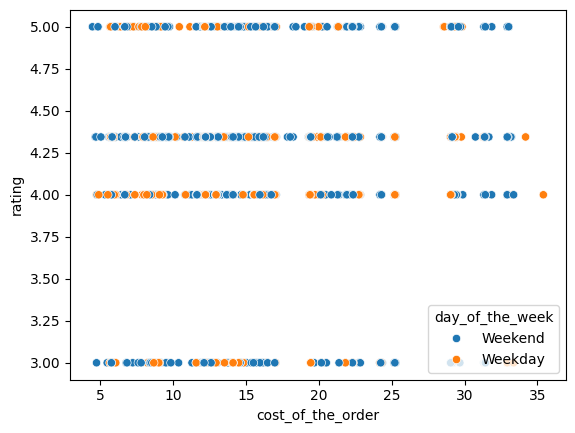

In [ ]:
#  Relationship between cost, rating, and Day of the Week
sns.scatterplot(data=df, x='cost_of_the_order', y='rating', hue='day_of_the_week')
plt.savefig("output.jpg", bbox_inches='tight')

<Axes: xlabel='cost_of_the_order', ylabel='delivery_time'>

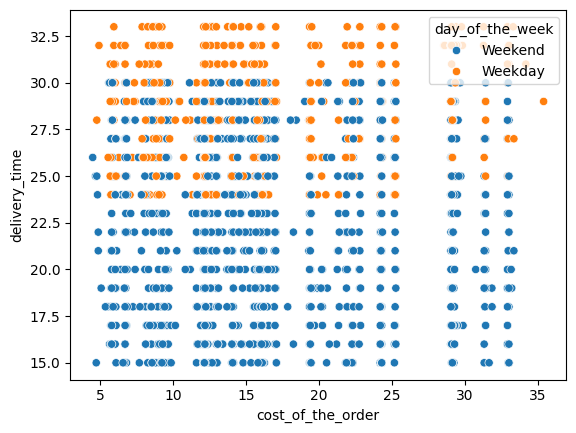

In [ ]:
sns.scatterplot(x='cost_of_the_order', y='delivery_time', hue='day_of_the_week', data=df)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, '15'),
  Text(1, 0, '16'),
  Text(2, 0, '17'),
  Text(3, 0, '18'),
  Text(4, 0, '19'),
  Text(5, 0, '20'),
  Text(6, 0, '21'),
  Text(7, 0, '22'),
  Text(8, 0, '23'),
  Text(9, 0, '24'),
  Text(10, 0, '25'),
  Text(11, 0, '26'),
  Text(12, 0, '27'),
  Text(13, 0, '28'),
  Text(14, 0, '29'),
  Text(15, 0, '30'),
  Text(16, 0, '31'),
  Text(17, 0, '32'),
  Text(18, 0, '33')])

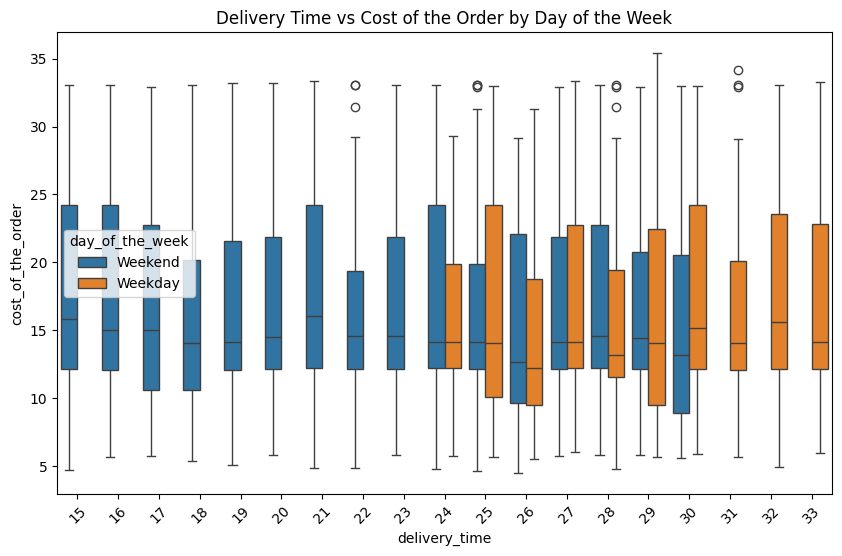

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='delivery_time', y='cost_of_the_order', hue='day_of_the_week')
plt.savefig("output.jpg", bbox_inches='tight')
plt.title('Delivery Time vs Cost of the Order by Day of the Week')
plt.xticks(rotation=45)

#### Observations: There's no significant relationship between delivery time and cost.  Day of the week introduces minor variation, but not enough to be meaningful on its own.

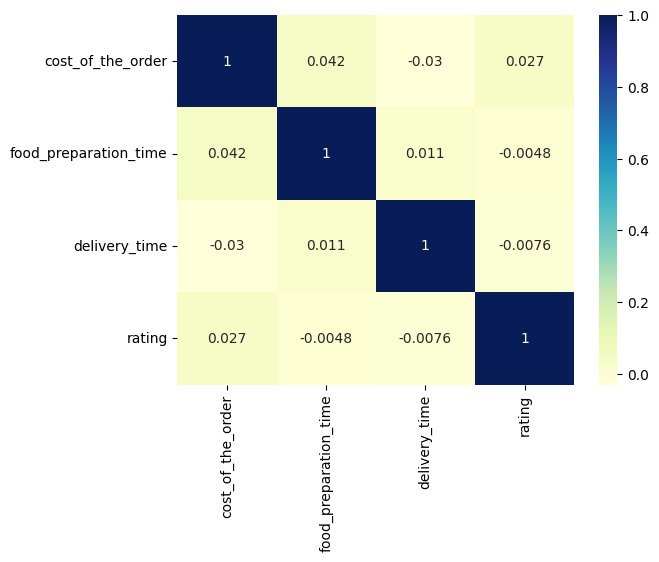

In [ ]:
sns.heatmap(df[['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']].corr(), annot=True, cmap='YlGnBu')
plt.savefig("output.jpg", bbox_inches='tight')

#### Observations: All variables are very weakly correlated or essentially independent of each other.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Group by restaurant name and calculate count and average of ratings
rating_stats = df.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Rename the columns for clarity
rating_stats.columns = ['rating_count', 'avg_rating']

# Filter based on the given conditions
eligible_restaurants = rating_stats[(rating_stats['rating_count'] > 50) & (rating_stats['avg_rating'] > 4)]

# Display the eligible restaurants
print(eligible_restaurants)


                           rating_count  avg_rating
restaurant_name                                    
Blue Ribbon Fried Chicken            96       4.333
Blue Ribbon Sushi                   119       4.268
Parm                                 68       4.220
RedFarm Broadway                     59       4.275
RedFarm Hudson                       55       4.241
Shake Shack                         219       4.304
The Meatball Shop                   132       4.451


#### Observations: Total 7 Restaurants having rating count of more than 50 and the average rating greater than 4.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
def calculate_commission(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0.0

# Apply the commission function to each order
df['revenue'] = df['cost_of_the_order'].apply(calculate_commission)

# Calculate total revenue
total_revenue = df['revenue'].sum()
print(f"Total net revenue generated by the company: ${total_revenue:.2f}")


Total net revenue generated by the company: $6166.30


#### Observations: Net Revenue: $6166.30

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
df['total_time']=df['food_preparation_time']+df['delivery_time']
total_orders = len(df)
orders_over_60 = df[df['total_time'] > 60].shape[0]
percentage_over_60 = (orders_over_60 / total_orders) * 100
print(percentage_over_60)

10.537407797681771


#### Observations: 10.53% Orders takes more than 60mins to get delivered once order is placed.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Write the code here
# Group by day_of_the_week and calculate mean delivery time
mean_delivery_time = df.groupby('day_of_the_week')['delivery_time'].mean()
print(mean_delivery_time)

day_of_the_week
Weekday   28.340
Weekend   22.470
Name: delivery_time, dtype: float64


#### Observations: Weekday orders take longer to deliver on average than weekend orders.

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
**1.Higher Order Volume on Weekends:**
There are more food orders on weekends, suggesting increased demand due to people staying in, socializing, or relaxing.

**2.American Cuisine Dominates:**
American cuisine is the most ordered cuisine across both weekdays and weekends, indicating strong customer preference.

**3.Customer Feedback Trends:**
Some restaurants consistently receive high ratings (above 4) and a large number of reviews, making them ideal for promotional partnerships.




### Recommendations:

*  **Leverage Popular Cuisines for Promotions:**
Focus marketing campaigns around American cuisine, as it is most in demand.
Additionally, encourage variety by offering discounts on less popular cuisines.

* **Upsell to Drive Higher Revenue:**
Promote combo meals or loyalty points to encourage customers to spend more than $20, increasing the company's 25% commission share.

* **Partner with High-Rated Restaurants:**
Promote restaurants with average ratings > 4 and more than 50 reviews through featured listings or homepage banners. These restaurants drive customer trust and repeat orders.



---